# SAM2 Positional Prune Entropy Heatmap Visualization

This notebook visualizes attention head entropy distribution using the POSITIONAL_PRUNE processor for SAM2.

## Overview
- Calibrates the POSITIONAL_PRUNE_SAM2 processor to collect entropy statistics
- Creates heatmaps showing entropy values across layers and heads
- Highlights which heads/positions are marked for pruning

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from omegaconf import OmegaConf
from collections import defaultdict

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.modeling.backbones.hieradet import MultiScaleAttention

from processors.encoder.entropy_sam2 import PositionalPruneSAM2Processor
from sam_engine import Engine

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All imports successful!")

/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwri

All imports successful!


## 2. Configuration

In [2]:
# Configuration parameters
CONFIG_FILE = 'quant/config/hq44k/rtn.yaml'
PROCESSOR_NAME = 'POSITIONAL_PRUNE_SAM2'
PERCENT_ENTROPY = 0.3  # Percentage of heads to prune based on entropy
NUM_CALIB_SAMPLES = 32  # Number of calibration samples
OUTPUT_DIR = './entropy_plots_sam2'
MODEL_CONFIG = '//home/chauht2/SAM_Quantization/sam2_configs/sam2.1/sam2.1_hiera_b+.yaml'
CHECKPOINT_PATH = './sam2_ckts/sam2.1_hiera_base_plus.pt'

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Processor: {PROCESSOR_NAME}")
print(f"  Percent Entropy: {PERCENT_ENTROPY}")
print(f"  Calibration Samples: {NUM_CALIB_SAMPLES}")
print(f"  Output Directory: {OUTPUT_DIR}")

Configuration:
  Processor: POSITIONAL_PRUNE_SAM2
  Percent Entropy: 0.3
  Calibration Samples: 32
  Output Directory: ./entropy_plots_sam2


## 3. Load Configuration and Model

In [3]:
# Load config
config = OmegaConf.load(CONFIG_FILE)
config.quantization.percent_entropy = PERCENT_ENTROPY
config.quantization.high_entropy = True

print("Config loaded:")
print(OmegaConf.to_yaml(config.quantization))

# Initialize SAM2 model
print(f"\nLoading SAM2 model from {CHECKPOINT_PATH}...")
sam2_model = build_sam2(MODEL_CONFIG, CHECKPOINT_PATH, device='cuda')
predictor = SAM2ImagePredictor(sam2_model)
print("Model loaded successfully!")

Config loaded:
quandecoder: false
quanrtn: true
low_high_density: none
quangptq: false
quansmooth: false
quanro: false
rtn_cuda: false
gptq_cuda: false
act_scales_file: ./pretrained_checkpoint/sam_vit_lactivation_scales.pt
act_quant: per_token
weight_quant: per_channel
n_bits: 4
n_bits_mlp: 4
quantize_output: false
up_down_RTN: none
qkT_v: true
channel: false
percent: 100
centerQ: false
percent_entropy: 0.3
percent_entropy_global: 0.5
high_entropy: true
prune_global: true


Loading SAM2 model from ./sam2_ckts/sam2.1_hiera_base_plus.pt...
Model loaded successfully!


## 4. Initialize Engine and Processor

In [4]:
# Initialize engine for dataloaders
print("Initializing engine...")
engine = Engine('entropy_viz_sam2', quantize_encoder=True, quantize_decoder=False)

# Initialize processor
print(f"\nInitializing {PROCESSOR_NAME} processor...")
processor = PositionalPruneSAM2Processor()

# Set up processor
# processor.set_dataloaders(engine.dataloaders)
# processor.set_accelerator(engine.accelerator)
processor.set_params(config)

print(f"Processor initialized: {processor.strategy_name}")
print(f"  Percent: {processor.percent}")
print(f"  Prune high entropy: {processor.prunehighentropy}")

Initializing engine...
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470

Initializing POSITIONAL_PRUNE_SAM2 processor...
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470
Processor initialized: PositionalHeadPruneSAM2Processor
  Percent: 0.3
  Prune high entropy: True


## 5. Calibrate Processor to Collect Entropy Statistics

In [5]:
print(f"\n{'='*80}")
print(f"Calibrating {PROCESSOR_NAME} with {NUM_CALIB_SAMPLES} samples...")
print(f"{'='*80}\n")

processor.calibrate(
    predictor=predictor,
    modules=MultiScaleAttention,
    num_samples=NUM_CALIB_SAMPLES
)

print("\n" + "="*80)
print("Calibration complete!")
print("="*80)


Calibrating POSITIONAL_PRUNE_SAM2 with 32 samples...

Registering attention hook for trunk.blocks.0.attn
Registering attention hook for trunk.blocks.1.attn
Registering attention hook for trunk.blocks.2.attn
Registering attention hook for trunk.blocks.3.attn
Registering attention hook for trunk.blocks.4.attn
Registering attention hook for trunk.blocks.5.attn
Registering attention hook for trunk.blocks.6.attn
Registering attention hook for trunk.blocks.7.attn
Registering attention hook for trunk.blocks.8.attn
Registering attention hook for trunk.blocks.9.attn
Registering attention hook for trunk.blocks.10.attn
Registering attention hook for trunk.blocks.11.attn
Registering attention hook for trunk.blocks.12.attn
Registering attention hook for trunk.blocks.13.attn
Registering attention hook for trunk.blocks.14.attn
Registering attention hook for trunk.blocks.15.attn
Registering attention hook for trunk.blocks.16.attn
Registering attention hook for trunk.blocks.17.attn
Registering attenti

INFO:root:Computing image embeddings for the provided image...


torch.Size([1024, 8, 8, 112])
nheads 2
q torch.Size([1024, 2, 64, 56])
k torch.Size([1024, 2, 64, 56])
v torch.Size([1024, 2, 64, 56])
torch.Size([1024, 8, 8, 112])
nheads 2
q torch.Size([1024, 2, 64, 56])
k torch.Size([1024, 2, 64, 56])
v torch.Size([1024, 2, 64, 56])
torch.Size([1024, 8, 8, 112])
nheads 4
q torch.Size([1024, 4, 16, 56])
k torch.Size([1024, 4, 64, 56])
v torch.Size([1024, 4, 64, 56])
torch.Size([1024, 4, 4, 224])
nheads 4
q torch.Size([1024, 4, 16, 56])
k torch.Size([1024, 4, 16, 56])
v torch.Size([1024, 4, 16, 56])
torch.Size([1024, 4, 4, 224])
nheads 4
q torch.Size([1024, 4, 16, 56])
k torch.Size([1024, 4, 16, 56])
v torch.Size([1024, 4, 16, 56])
torch.Size([1024, 4, 4, 224])
nheads 8
q torch.Size([1024, 8, 4, 56])
k torch.Size([1024, 8, 16, 56])
v torch.Size([1024, 8, 16, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8,

INFO:root:Image embeddings computed.
INFO:root:Computing image embeddings for the provided image...


torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([1, 64, 64, 448])
nheads 8
q torch.Size([1, 8, 4096, 56])
k torch.Size([1, 8, 4096, 56])
v torch.Size([1, 8, 4096, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([1, 64, 64, 448])
nheads 8
q torch.Size([1, 8, 4096, 56])
k torch.

...

INFO:root:Image embeddings computed.
INFO:root:Computing image embeddings for the provided image...


torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([1, 64, 64, 448])
nheads 8
q torch.Size([1, 8, 4096, 56])
k torch.Size([1, 8, 4096, 56])
v torch.Size([1, 8, 4096, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch

INFO:root:Image embeddings computed.

torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch.Size([25, 8, 196, 56])
v torch.Size([25, 8, 196, 56])
torch.Size([1, 64, 64, 448])
nheads 8
q torch.Size([1, 8, 4096, 56])
k torch.Size([1, 8, 4096, 56])
v torch.Size([1, 8, 4096, 56])
torch.Size([25, 14, 14, 448])
nheads 8
q torch.Size([25, 8, 196, 56])
k torch

Calculating final entropy variance and mean from accumulated data...
Layer image_encoder.trunk.blocks.0.attn: 614 heads marked: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]...
Layer image_encoder.trunk.blocks.1.attn: 614 heads marked: [44, 46, 60, 62, 66, 68, 70, 72, 73, 74]...
Layer image_encoder.trunk.blocks.2.attn: 1228 heads marked: [11, 15, 17, 19, 21, 23, 25, 27, 29, 31]...
Layer image_encoder.trunk.blocks.3.attn: 1228 heads marked: [0, 2, 4, 6, 8, 12, 16, 18, 20, 22]...
Layer image_encoder.trunk.blocks.4.attn: 1228 heads marked: [0, 1, 5, 9, 13, 16, 17, 20, 21, 24]...
Layer image_encoder.trunk.blocks.5.attn: 2457 heads marked: [1, 2, 6, 9, 10, 14, 17, 18, 22, 25]...
Layer image_encoder.trunk.blocks.6.attn: 100 heads marked: [1, 2, 3, 5, 7, 9, 10, 11, 15, 17]...
Layer image_encoder.trunk.blocks.7.attn: 100 heads marked: [0, 1, 3, 6, 8, 10, 11, 14, 16, 19]...
Layer image_encoder.trunk.blocks.8.attn: 100 heads marked: [3, 4, 5, 6, 11, 12, 13, 14, 19, 20]...
Layer image_encoder.trunk.blocks.

## 6. Extract Entropy Statistics

In [6]:
def extract_entropy_statistics(processor):
    """Extract entropy statistics from calibrated processor."""
    if not hasattr(processor, 'entropy_stats'):
        print("Warning: Processor has no entropy_stats attribute")
        return {}

    print(f"\nExtracting entropy statistics from {processor.strategy_name}...")
    print(f"Found {len(processor.entropy_stats)} head entries")

    # Group by layer and head
    layer_head_entropy = {}

    for head_key, entropy_values in processor.entropy_stats.items():
        if len(entropy_values) == 0:
            continue

        # Parse key format: 'trunk.blocks.0.attn.head_0'
        parts = head_key.split('.')
        if len(parts) < 4:
            continue

        # Find block index after 'blocks'
        if 'blocks' in parts:
            block_idx = int(parts[parts.index('blocks') + 1])
        else:
            continue

        head_idx = int(parts[-1].split('_')[1])

        # Calculate mean entropy
        entropy_tensor = torch.tensor(entropy_values) if not isinstance(entropy_values[0], torch.Tensor) else torch.stack(entropy_values)
        mean_entropy = torch.mean(entropy_tensor).item()

        layer_name = f"Block {block_idx}"
        if layer_name not in layer_head_entropy:
            layer_head_entropy[layer_name] = {}

        layer_head_entropy[layer_name][head_idx] = mean_entropy

    print(f"Organized into {len(layer_head_entropy)} layers")
    return layer_head_entropy


def extract_pruning_masks(processor):
    """Extract pruning masks from calibrated processor."""
    if not hasattr(processor, 'final_entropy_stats'):
        print("Warning: Processor has no final_entropy_stats attribute")
        return {}

    print(f"\nExtracting pruning masks...")
    print(f"Found {len(processor.final_entropy_stats)} layers with masks")

    masks = {}
    for layer_name, mask_data in processor.final_entropy_stats.items():
        # Convert layer name format: 'image_encoder.trunk.blocks.0.attn' -> 'Block 0'
        parts = layer_name.split('.')
        if 'blocks' in parts:
            block_idx = int(parts[parts.index('blocks') + 1])
            simple_name = f"Block {block_idx}"
            masks[simple_name] = mask_data

    return masks


# Extract statistics
layer_head_entropy = extract_entropy_statistics(processor)
pruning_masks = extract_pruning_masks(processor)

if not layer_head_entropy:
    print("\nError: No entropy statistics found!")
else:
    print(f"\nSuccessfully extracted entropy data for {len(layer_head_entropy)} layers")


Extracting entropy statistics from PositionalHeadPruneSAM2Processor...
Found 28200 head entries
Organized into 24 layers

Extracting pruning masks...
Found 24 layers with masks

Successfully extracted entropy data for 24 layers


## 7. Print Entropy Summary Statistics

In [7]:
print("\n" + "="*80)
print("ENTROPY SUMMARY")
print("="*80)

all_entropies = []
for layer_data in layer_head_entropy.values():
    all_entropies.extend(layer_data.values())

print(f"Total heads/positions tracked: {len(all_entropies)}")
print(f"Mean entropy: {np.mean(all_entropies):.4f}")
print(f"Std entropy: {np.std(all_entropies):.4f}")
print(f"Min entropy: {np.min(all_entropies):.4f}")
print(f"Max entropy: {np.max(all_entropies):.4f}")
print(f"Median entropy: {np.median(all_entropies):.4f}")

if pruning_masks:
    total_pruned = sum(
        mask.sum().item() if isinstance(mask, torch.Tensor) else len(mask)
        for mask in pruning_masks.values()
    )
    print(f"\nTotal pruned elements: {total_pruned}")
    
    # Calculate pruning ratio
    total_elements = len(all_entropies)
    pruning_ratio = total_pruned / total_elements if total_elements > 0 else 0
    print(f"Pruning ratio: {pruning_ratio:.2%}")

print("="*80)


ENTROPY SUMMARY
Total heads/positions tracked: 28200
Mean entropy: 0.1017
Std entropy: 0.0518
Min entropy: 0.0009
Max entropy: 0.1681
Median entropy: 0.1042

Total pruned elements: 8941
Pruning ratio: 31.71%


## 8. Visualize Entropy Distribution - Individual Layers

In [8]:
# Example: Visualize entropy for specific blocks
# SAM2 Hiera-L has different layer structure than SAM1
# You can inspect layer_head_entropy.keys() to see available blocks

print("Available blocks:", sorted(layer_head_entropy.keys()))

Available blocks: ['Block 0', 'Block 1', 'Block 10', 'Block 11', 'Block 12', 'Block 13', 'Block 14', 'Block 15', 'Block 16', 'Block 17', 'Block 18', 'Block 19', 'Block 2', 'Block 20', 'Block 21', 'Block 22', 'Block 23', 'Block 3', 'Block 4', 'Block 5', 'Block 6', 'Block 7', 'Block 8', 'Block 9']


In [9]:
len(layer_head_entropy['Block 6'])

200

In [10]:
sam2_model.image_encoder.trunk.blocks[0].attn.num_heads

2

Block 21: 16 head positions
(16, 25)


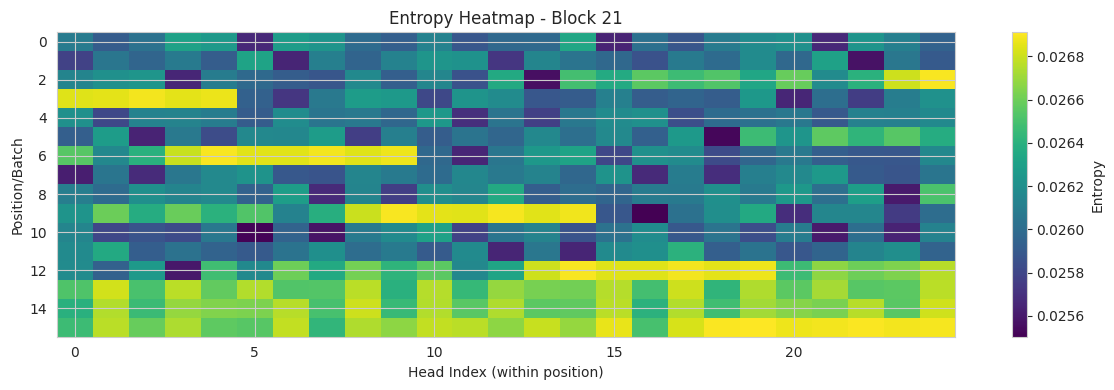

In [14]:
# Visualize a specific block (adjust block_idx as needed)
block_idx =21 
layer_name = f'Block {block_idx}'

if layer_name in layer_head_entropy:
    entropy = np.array(list(layer_head_entropy[layer_name].values()))
    
    # Determine reshape dimensions based on number of heads
    num_heads = sam2_model.image_encoder.trunk.blocks[block_idx].attn.num_heads
    print(f"Block {block_idx}: {num_heads} head positions")
    
    # Try to find a good reshape (square-ish)
    entropy_2d = entropy.reshape(num_heads, -1)
    print(entropy_2d.shape)

    
    plt.figure(figsize=(12, 4))
    plt.imshow(entropy_2d, aspect='auto', cmap='viridis')
    plt.colorbar(label='Entropy')
    plt.title(f'Entropy Heatmap - {layer_name}')
    plt.xlabel('Head Index (within position)')
    plt.ylabel('Position/Batch')
    plt.tight_layout()
    plt.show()
else:
    print(f"Layer {layer_name} not found in entropy data")

## 9. Visualize All Layers

Block 0: 2 head positions
(2048,)
(2, 1024)
Block 1: 2 head positions
(2048,)
(2, 1024)
Block 2: 4 head positions
(4096,)
(4, 1024)
Block 3: 4 head positions
(4096,)
(4, 1024)
Block 4: 4 head positions
(4096,)
(4, 1024)
Block 5: 8 head positions
(8192,)
(8, 1024)
Block 6: 8 head positions
(200,)
(8, 25)
Block 7: 8 head positions
(200,)
(8, 25)
Block 8: 8 head positions
(200,)
(8, 25)
Block 9: 8 head positions
(200,)
(8, 25)
Block 10: 8 head positions
(200,)
(8, 25)
Block 11: 8 head positions
(200,)
(8, 25)
Block 12: 8 head positions
(8,)
(8, 1)
Block 13: 8 head positions
(200,)
(8, 25)
Block 14: 8 head positions
(200,)
(8, 25)
Block 15: 8 head positions
(200,)
(8, 25)
Block 16: 8 head positions
(8,)
(8, 1)
Block 17: 8 head positions
(200,)
(8, 25)
Block 18: 8 head positions
(200,)
(8, 25)
Block 19: 8 head positions
(200,)
(8, 25)
Block 20: 8 head positions
(8,)
(8, 1)
Block 21: 16 head positions
(400,)
(16, 25)
Block 22: 16 head positions
(400,)
(16, 25)
Block 23: 16 head positions
(40

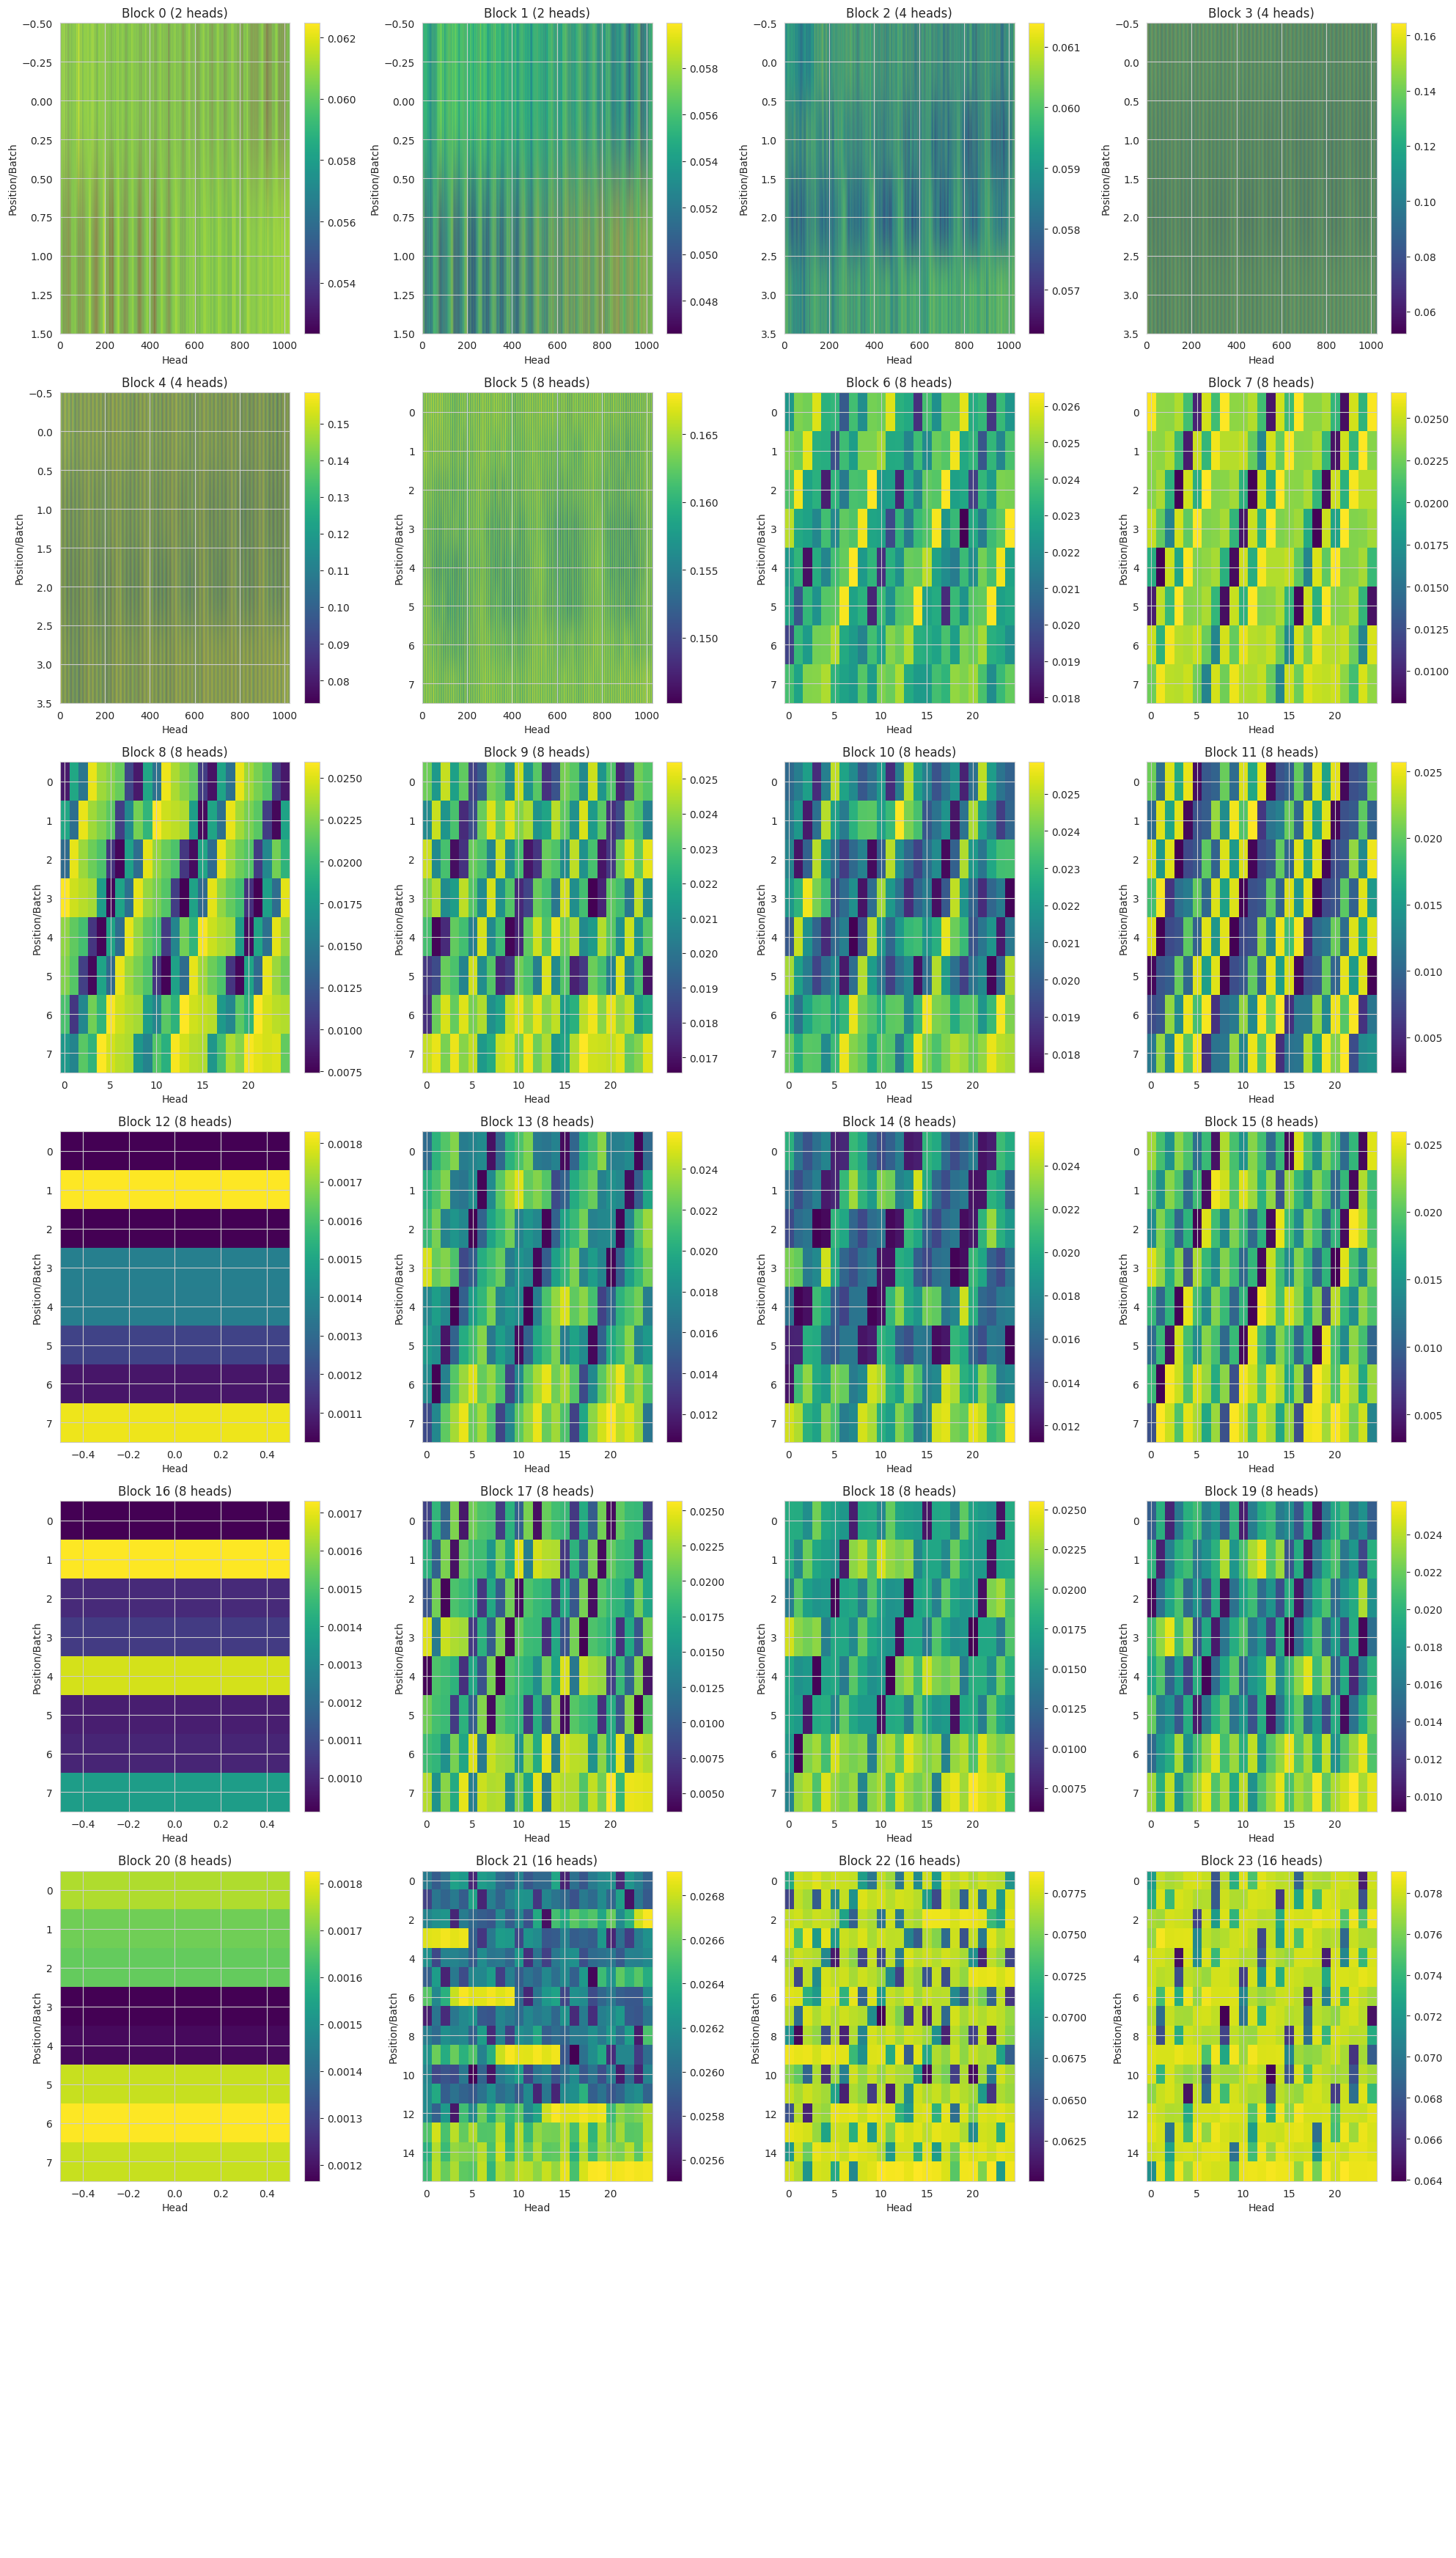

Saved heatmap to ./entropy_plots_sam2/all_layers_entropy_heatmap.png


In [15]:
# Plot entropy distribution for all layers
num_layers = len(layer_head_entropy)
fig, axes = plt.subplots(num_layers // 4 + 1, 4, figsize=(20, 5 * (num_layers // 4 + 1)))
axes = axes.flatten()

for idx, layer_name in enumerate(layer_head_entropy):
    entropy = np.array(list(layer_head_entropy[layer_name].values()))
    num_heads = len(entropy)
    
    # Determine reshape
    num_heads = sam2_model.image_encoder.trunk.blocks[idx].attn.num_heads
    print(f"Block {idx}: {num_heads} head positions")
    
    # Try to find a good reshape (square-ish)
    print(entropy.shape)
    entropy_2d = entropy.reshape(num_heads, -1)
    print(entropy_2d.shape)

    
    im = axes[idx].imshow(entropy_2d, aspect='auto', cmap='viridis')
    axes[idx].set_title(f'{layer_name} ({num_heads} heads)')
    axes[idx].set_xlabel('Head')
    axes[idx].set_ylabel('Position/Batch')
    plt.colorbar(im, ax=axes[idx])

# Hide unused subplots
for idx in range(len(layer_head_entropy), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/all_layers_entropy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved heatmap to {OUTPUT_DIR}/all_layers_entropy_heatmap.png")

## 10. Analyze Entropy Distribution Across Layers

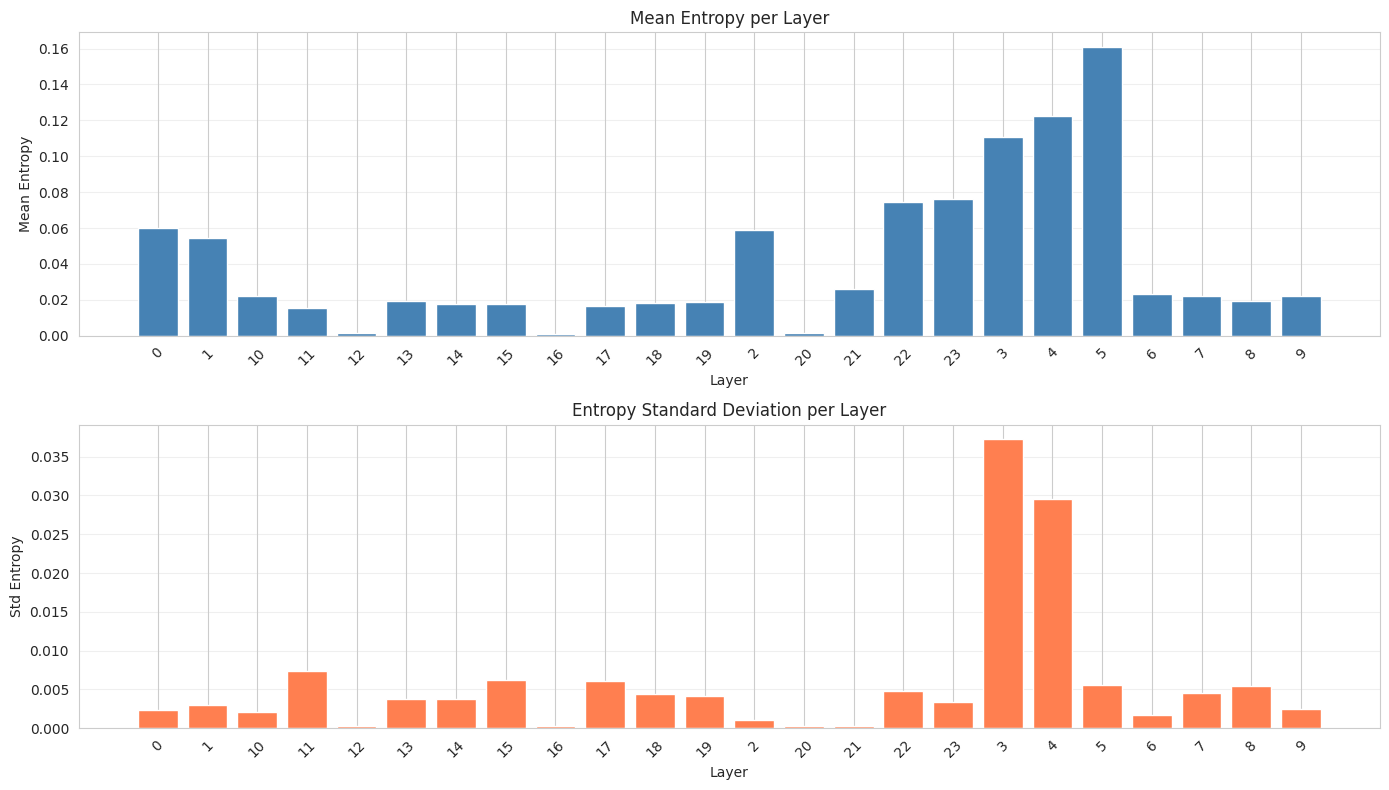

Saved distribution plot to ./entropy_plots_sam2/entropy_distribution_per_layer.png


In [16]:
# Plot entropy statistics per layer
layer_names = sorted(layer_head_entropy.keys())
layer_means = [np.mean(list(layer_head_entropy[name].values())) for name in layer_names]
layer_stds = [np.std(list(layer_head_entropy[name].values())) for name in layer_names]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Mean entropy per layer
ax1.bar(range(len(layer_names)), layer_means, color='steelblue')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Mean Entropy')
ax1.set_title('Mean Entropy per Layer')
ax1.set_xticks(range(len(layer_names)))
ax1.set_xticklabels([name.replace('Block ', '') for name in layer_names], rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Std entropy per layer
ax2.bar(range(len(layer_names)), layer_stds, color='coral')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Std Entropy')
ax2.set_title('Entropy Standard Deviation per Layer')
ax2.set_xticks(range(len(layer_names)))
ax2.set_xticklabels([name.replace('Block ', '') for name in layer_names], rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/entropy_distribution_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved distribution plot to {OUTPUT_DIR}/entropy_distribution_per_layer.png")

## 11. Inspect Raw Entropy Values

In [17]:
# Display the layer_head_entropy dictionary structure
print("Layer head entropy data structure:")
for layer_name in sorted(layer_head_entropy.keys())[:3]:  # Show first 3 layers
    entropy_dict = layer_head_entropy[layer_name]
    print(f"\n{layer_name}: {len(entropy_dict)} heads")
    print(f"  Sample values: {list(entropy_dict.values())[:5]}")

Layer head entropy data structure:

Block 0: 2048 heads
  Sample values: [0.057024940848350525, 0.062227461487054825, 0.05746348574757576, 0.06211887300014496, 0.05775544047355652]

Block 1: 2048 heads
  Sample values: [0.05524326115846634, 0.05208263918757439, 0.055573828518390656, 0.053850531578063965, 0.05573134869337082]

Block 10: 200 heads
  Sample values: [0.020340275019407272, 0.021061470732092857, 0.02216632291674614, 0.018551869317889214, 0.02110067754983902]


: 